---
# **This note book contains 2 tests:**
## 1. Cosine Similarity Test (OLD ONE)
## 2. RANK TEST

In [1]:
import os
import json
from datetime import datetime
import sys
sys.path.append("/home/ppathak2/Hypothesis_Generation_Active_Learning")
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# Path to the BATS Dataset - 
PATH_BATS_dataset_root = "/home/ppathak2/Hypothesis_Generation_Active_Learning/datasets/BATS_3.0"
PATH_context_tree_output = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS_test"

In [4]:
# Let's Load the dataset in an intuitive way using pandas:
# SERIES_rel_cat = pd.S
BATS_categories = {}
for category in os.listdir(PATH_BATS_dataset_root):
    path_category = os.path.join(PATH_BATS_dataset_root, category)
    if os.path.isdir(path_category):
        category_content = [] 

        for category_type_file in tqdm(os.listdir(path_category), desc=f'Processing - {category}'):
            path_category_type_file = os.path.join(path_category, category_type_file)
            id, relation_category = category_type_file.rsplit('].')[0].split(' [')
            with open(path_category_type_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    line = line.split()
                    row = {"Id" : id, "relation-category": relation_category, 
                     "value1": line[0], "value2": line[1]}
                    category_content.append(row)
        BATS_categories[category[2:]] = category_content

DF_Inflectional_morphology = pd.DataFrame(BATS_categories['Inflectional_morphology'])
DF_Derivational_morphology = pd.DataFrame(BATS_categories['Derivational_morphology'])
DF_Encyclopedic_semantics = pd.DataFrame(BATS_categories['Encyclopedic_semantics'])
DF_Lexicographic_semantics = pd.DataFrame(BATS_categories['Lexicographic_semantics'])

Processing - 3_Encyclopedic_semantics: 100%|██████████| 10/10 [00:00<00:00, 1506.74it/s]


Processing - 4_Lexicographic_semantics: 100%|██████████| 10/10 [00:00<00:00, 1356.15it/s]


In [5]:
DF_Lexicographic_semantics.head()

,Id,relation-category,value1,value2
0,L08,synonyms - exact,airplane,aeroplane/plane
1,L08,synonyms - exact,auto,car/automobile/motorcar
2,L08,synonyms - exact,baby,infant/babe
3,L08,synonyms - exact,bicycle,bike/wheel/cycle
4,L08,synonyms - exact,child,kid/youngster/minor/shaver/nipper/small_fry/tiddler/tike/tyke/fry/nestling


In [6]:
test_time = datetime.now().strftime("%m-%d %H:%M:%S")
PATH_output = os.path.join(PATH_context_tree_output, test_time)

In [7]:
DF_Encyclopedic_semantics["relation-category"].head()

0    UK_city - county
1    UK_city - county
2    UK_city - county
3    UK_city - county
4    UK_city - county
Name: relation-category, dtype: object

---
# **1. Cosine Similarity Test (OLD ONE)**
## Let's Test the Gender Test first:
## 1. We are using the `Encyclopedic_semantics` -> `E10 [male - female].txt`

In [8]:

value1_male = DF_Encyclopedic_semantics.where(DF_Encyclopedic_semantics['relation-category'] ==  'male - female').dropna().value1.to_list()
value2_female = DF_Encyclopedic_semantics.where(DF_Encyclopedic_semantics['relation-category'] ==  'male - female').dropna().value2.to_list()

print(value1_male)
print(value2_female)

['actor', 'batman', 'boar', 'boy', 'brother', 'buck', 'bull', 'businessman', 'chairman', 'dad', 'daddy', 'duke', 'emperor', 'father', 'fisherman', 'fox', 'gentleman', 'god', 'grandfather', 'grandpa', 'grandson', 'groom', 'headmaster', 'heir', 'hero', 'hound', 'husband', 'king', 'lion', 'man', 'manager', 'mister', 'murderer', 'nephew', 'poet', 'policeman', 'prince', 'ram', 'rooster', 'sculptor', 'sir', 'son', 'stallion', 'stepfather', 'superman', 'tiger', 'uncle', 'valet', 'waiter', 'webmaster']
['actress', 'batwoman', 'sow', 'girl', 'sister', 'doe', 'cow', 'businesswoman', 'chairwoman', 'mom/mum', 'mommy/mother/mom', 'duchess', 'empress', 'mother', 'fisherwoman', 'vixen', 'lady/gentlewoman/madam', 'goddess', 'grandmother', 'grandma', 'granddaughter', 'bride', 'headmistress', 'heiress', 'heroine', 'bitch', 'wife', 'queen', 'lioness', 'woman', 'manageress', "miss/missis/missus/mis'ess/mrs/ms/madam", 'murderess', 'niece', 'poetess', 'policewoman', 'princess', 'ewe', 'hen', 'sculptress', '

## Let's do a sample test:
1. I will load the context embedding for `depth=3`, and `num_trees=1` per keyword. Let's try the male female test.
2. I will also vizualize the results from `all_distinct_layers` of the embedding model.

In [9]:
def load_final_ctx_emb_dataset(PATH_final_emb):

    ctx_emb_dataset = {}
    for keyword in os.listdir(PATH_final_emb):
        path_keyword =  os.path.join(PATH_final_emb, keyword)
        if os.path.isdir(path_keyword):
            ctx_emb_dataset[keyword] = []
            all_jsons = os.listdir(path_keyword)
            all_jsons.remove('missing.json')
            for json_file in all_jsons:
                with open(os.path.join(path_keyword, json_file), 'r') as f:
                    data = json.load(f)
                    data = data['run_1']
                    final_emb = data['final_embedding']
                    raw_root_emb = data['raw_root_embedding']

                    # converting these into numpy arrays:
                    final_emb = np.array(final_emb)
                    raw_root_emb = np.array(raw_root_emb)

                    row = {'layer_strategy': json_file.rsplit('.json')[0].split('final_1_')[1],
                        'final_emb':final_emb,
                        'raw_root_emb': raw_root_emb}
                    ctx_emb_dataset[keyword].append(row)
    return ctx_emb_dataset

In [10]:
the2_pairs = r'''
buck	doe
businessman	businesswoman
'''
a_b, c_d = the2_pairs.strip().split('\n')
a, b = a_b.split('\t')
c, d = c_d.split('\t')

In [11]:
PATH_final_emb = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS/female-male-batch/male - female_final_embd"

ctx_emb_dataset = load_final_ctx_emb_dataset(PATH_final_emb)


# converting them 2 4 dataframes-
DF_ctx_emb_actor = pd.DataFrame(ctx_emb_dataset[a])
DF_ctx_emb_actress = pd.DataFrame(ctx_emb_dataset[b]) 
DF_ctx_emb_batman = pd.DataFrame(ctx_emb_dataset[c])
DF_ctx_emb_batwoman = pd.DataFrame(ctx_emb_dataset[d])

In [12]:
DF_ctx_emb_actor['layer_strategy']

0          first
1    first_three
2     last_three
3      first_two
4       last_two
5           last
Name: layer_strategy, dtype: object

In [13]:
DF_ctx_emb_actor['final_emb'][0].shape

(768,)

## Now, performing the `a:b :: b:c` test in each category:

In [14]:
def cosine_similarity(v1, v2, do_abs=False):
    """
    Calculates the cosine similarity between two NumPy vectors.
    
    Args:
        v1: First vector (numpy array)
        v2: Second vector (numpy array)
        do_abs: If True, returns absolute value of cosine similarity
    
    Returns:
        Cosine similarity value (signed or absolute based on do_abs)
    """
    dot_product = np.dot(v1, v2.T)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    if magnitude_v1 == 0 or magnitude_v2 == 0:
        return 0  # Handle cases with zero vectors to avoid division by zero

    cos_sim = dot_product / (magnitude_v1 * magnitude_v2)
    
    return abs(cos_sim) if do_abs else cos_sim

def run_bats_analogy_test(df_A: pd.DataFrame, df_B: pd.DataFrame,
                          df_C: pd.DataFrame, df_D: pd.DataFrame):
    layer_strategies = df_A['layer_strategy'].to_list()
    results = {}
    for layer_strategy in layer_strategies:
        results[layer_strategy] = {}

        # performing the a:b :: c:d test for final embeddings:
        a_final_emb = df_A[df_A['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]
        b_final_emb = df_B[df_B['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]
        c_final_emb = df_C[df_C['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]
        d_final_emb = df_D[df_D['layer_strategy'] == layer_strategy]['final_emb'].iloc[0]

        # the predicated final embedding can be calculated using the formula a = (c - d) + b
        predicted_a_final_emb = (c_final_emb - d_final_emb) + b_final_emb
        # predicted_d_final_emb = c_final_emb + (b_final_emb - a_final_emb)
        final_emb_cosine_sim = cosine_similarity(predicted_a_final_emb, a_final_emb)
        results[layer_strategy]['final_emb'] = {
            'predicted_a_final_emb': predicted_a_final_emb,
            'actual_a_final_emb': a_final_emb,
            'cosine_similarity': float(final_emb_cosine_sim)
        }

        # Doing the same for raw_root_emb:
        a_raw_root_emb = df_A[df_A['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        b_raw_root_emb = df_B[df_B['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        c_raw_root_emb = df_C[df_C['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        d_raw_root_emb = df_D[df_D['layer_strategy'] == layer_strategy]['raw_root_emb'].iloc[0]
        # predicted_d_raw_root_emb = c_raw_root_emb + (b_raw_root_emb - a_raw_root_emb)
        predicted_a_raw_root_emb = (c_raw_root_emb - d_raw_root_emb) + b_raw_root_emb
        raw_root_emb_cosine_sim = cosine_similarity(predicted_a_raw_root_emb, a_raw_root_emb)
        # print(layer_strategy)
        results[layer_strategy]['raw_root_emb'] = {
            'predicted_a_raw_root_emb': predicted_a_raw_root_emb,
            'actual_a_raw_root_emb': a_raw_root_emb,
            'cosine_similarity': float(raw_root_emb_cosine_sim)
        }
    return results

In [15]:
def plot_cosine_similarities(results, title):
    layer_strategies = list(results.keys())
    final_emb_cosine_similarities = [results[strategy]['final_emb']['cosine_similarity'] for strategy in layer_strategies]
    raw_root_emb_cosine_similarities = [results[strategy]['raw_root_emb']['cosine_similarity'] for strategy in layer_strategies]

    x = range(len(layer_strategies))
    width = 0.2
    # need to make sure the ticks on y-axis is 0.2 and is between 0 to 1:
    
    plt.figure(figsize=(10, 6))
    plt.bar(x, final_emb_cosine_similarities, width, label='Final Context Embedding')
    plt.bar([i + width for i in x], raw_root_emb_cosine_similarities, width, label='Raw Root Embedding')

    plt.xlabel('Layer Strategies')
    plt.ylabel('Cosine Similarity')
    plt.title(title)
    plt.xticks([i + width/2 for i in x], layer_strategies, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3719140/4235922348.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'cosine_similarity': float(raw_root_emb_cosine_sim)


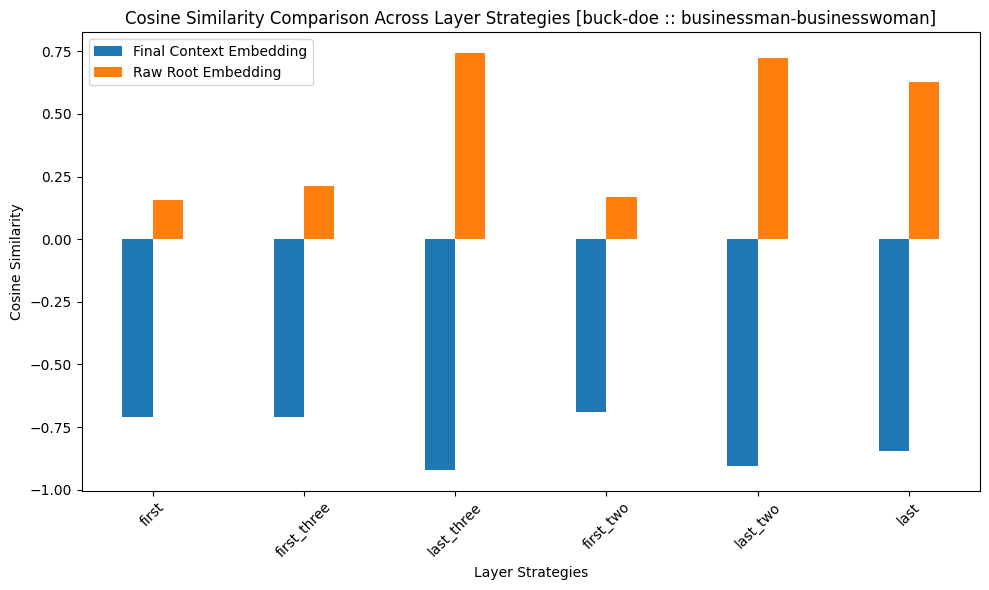

In [16]:
results = run_bats_analogy_test(DF_ctx_emb_actor, DF_ctx_emb_actress,
                      DF_ctx_emb_batman, DF_ctx_emb_batwoman)


# Plotting cosine similarities for all strategies as a bar chart:
title = f'Cosine Similarity Comparison Across Layer Strategies [{a}-{b} :: {c}-{d}]'
plot_cosine_similarities(results, title)

---
# **2. RANK TEST**
## The Individual Tests seems to show good Results? Working on the Rank Test:

In [ ]:
# Doing the test for the gender set:
# PATH_context_forest = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS/female-male-batch/male - female_final_embd"
PATH_context_forest = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees/BATS_BERT/female-male-batch/male - female"
PATH_BATS_gender_file = "/home/ppathak2/Hypothesis_Generation_Active_Learning/datasets/BATS_3.0/3_Encyclopedic_semantics/E10 [male - female].txt"

## I. Let's start by building utility functions for this test:

> ### **TODO**: 
>> We need to add the SciBERT as our base-line and perform the same test and compare the results.
>>> For each set of keywords from a file, from the 2nd coloumn of pairs, we are only taking the first element. (I.e. if a pair is `**mister**	**miss**/missis/missus/mis'ess/mrs/ms/madam`, we are only taking `**mister**	**miss**`)

In [18]:
# Function to load any given BATS file and create all possible combinations:
def load_bats_pairs_and_combinations(path_bats_file, ctx_emb_dataset):
    """
    Loads pairs from BATS file and creates all possible combinations.
    Each entry (line) is treated as one element, and we create pairs with any other element.
    
    Args:
        path_bats_file: Path to the BATS txt file (e.g., E10 [male - female].txt)
        ctx_emb_dataset: Dictionary containing context embeddings for all keywords
    
    Returns:
        tuple: (elements, combinations)
            - elements: List of tuples [(male_term, female_terms_list), ...]
            - combinations: List of dicts with 'elem1', 'elem2', and 'metadata' keys
                metadata contains dataframes for m1, w1, m2, w2
    """
    # Load all elements from the file
    elements = []
    with open(path_bats_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            line = line.strip()
            if line:  # Skip empty lines
                parts = line.split('\t')
                if len(parts) == 2:
                    male_term = parts[0].strip()
                    # Split female terms by '/' and create a list
                    # female_terms = [term.strip() for term in parts[1].split('/')]
                    # Taking only the first element for now:
                    female_terms = [parts[1].strip().split('/')[0]]
                    elements.append((male_term, female_terms))
    
    # Create all combinations of one element with any other element
    combinations = []
    for i in tqdm(range(len(elements))):
        for j in range(len(elements)):
            if i != j:  # Don't pair an element with itself
                m1, w1_list = elements[i]
                m2, w2_list = elements[j]
                w1 = w1_list[0]
                w2 = w2_list[0]
                
                # Create dataframes for all four terms
                metadata = {
                    'DF_m1': pd.DataFrame(ctx_emb_dataset[m1]),
                    'DF_w1': pd.DataFrame(ctx_emb_dataset[w1]),
                    'DF_m2': pd.DataFrame(ctx_emb_dataset[m2]),
                    'DF_w2': pd.DataFrame(ctx_emb_dataset[w2])
                }
                
                combinations.append({
                    'elem1': elements[i],
                    'elem2': elements[j],
                    'metadata': metadata
                })
    
    return elements, combinations

In [19]:
# Need a function to extract all embeddings for `m1`:
def extract_all_m1(combinations):
    all_m1_embeddings = {}
    for combo in combinations:
        m1, _ = combo['elem1']
        if m1 not in all_m1_embeddings:
            all_m1_embeddings[m1] = combo['metadata']['DF_m1']
    return all_m1_embeddings

In [20]:
# First load the context embeddings
ctx_emb_dataset = load_final_ctx_emb_dataset(PATH_final_emb)

# Load the pairs and generate all combinations
elements, combinations = load_bats_pairs_and_combinations(PATH_BATS_gender_file, ctx_emb_dataset)

print(f"Loaded {len(elements)} elements from the BATS file")
print(f"Generated {len(combinations)} combinations")
print(f"\nFirst 3 elements:")
for i, (male, female_list) in enumerate(elements[:3]):
    print(f"  {i+1}. {male} -> {female_list}")

print(f"\nFirst 5 combinations:")
for i, combo in enumerate(combinations[:5]):
    elem1, elem2 = combo['elem1'], combo['elem2']
    male1, female1_list = elem1
    male2, female2_list = elem2
    print(f"  {i+1}. ({male1}, {female1_list}) paired with ({male2}, {female2_list})")

# Now extracting embeddings for all m1 terms:
all_m1_embeddings = extract_all_m1(combinations)
print(f"\nExtracted embeddings for {len(all_m1_embeddings)} unique m1 terms.")

100%|██████████| 50/50 [00:01<00:00, 34.41it/s]

Loaded 50 elements from the BATS file
Generated 2450 combinations

First 3 elements:
  1. actor -> ['actress']
  2. batman -> ['batwoman']
  3. boar -> ['sow']

First 5 combinations:
  1. (actor, ['actress']) paired with (batman, ['batwoman'])
  2. (actor, ['actress']) paired with (boar, ['sow'])
  3. (actor, ['actress']) paired with (boy, ['girl'])
  4. (actor, ['actress']) paired with (brother, ['sister'])
  5. (actor, ['actress']) paired with (buck, ['doe'])

Extracted embeddings for 50 unique m1 terms.


## II. We need a function that calculates $E_{q}$:
1. Given $E_{m1}$, $E_{w1}$, $E_{m2}$, $E_{w2}$ ; Where $E_{m1}$ and $E_{w1}$ are pairs and so are $E_{m2}$ and $E_{w2}$ ;
2. $E_q$ is Given by: 
    > $E_q = (E_{m2} - E_{w2}) + E_{w1}$

The final test results will be a bar-plot with 5 plots:
1. top 1, top 2, top 3, top 5, top 10

In each plot:
1. We do plot all `layering_strategy`
2. And we plot the `final_emb` vs `raw_root_emb`


In [21]:
# Function to rank all m1 embeddings against the predicted Eq for a given layer strategy and embedding type
def rank_m1_against_Eq(Eq_embedding, all_m1_embeddings, layer_strategy, emb_type='final_emb'):
    """
    Ranks all m1 keywords based on cosine similarity between their embeddings and the predicted Eq.
    
    Args:
        Eq_embedding: The predicted embedding vector (numpy array)
        all_m1_embeddings: Dictionary of {m1_keyword: DataFrame with embeddings}
        layer_strategy: Which layer strategy to use (e.g., 'first', 'last_three', etc.)
        emb_type: Either 'final_emb' or 'raw_root_emb'
    
    Returns:
        List of tuples: [(m1_keyword, cosine_similarity), ...] sorted by similarity (descending)
    """
    similarities = []
    
    for m1_keyword, df_m1 in all_m1_embeddings.items():
        # Get the embedding for this m1 keyword with the specified layer strategy
        m1_emb = df_m1[df_m1['layer_strategy'] == layer_strategy][emb_type].iloc[0]
        
        # Calculate cosine similarity
        cos_sim = cosine_similarity(Eq_embedding, m1_emb)
        similarities.append((m1_keyword, float(cos_sim)))
    
    # Sort by cosine similarity in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    return similarities


def calculate_topk_accuracy(ranked_list, true_m1, k_values=[1, 2, 3, 5, 10]):
    """
    Calculates if the true_m1 is in the top-k of the ranked list.
    
    Args:
        ranked_list: List of tuples [(m1_keyword, cosine_similarity), ...]
        true_m1: The actual m1 keyword we're looking for
        k_values: List of k values to check
    
    Returns:
        Dictionary: {k: 1 if true_m1 in top-k else 0}
    """
    topk_results = {}
    
    # Get the rank of true_m1
    true_m1_rank = None
    for rank, (keyword, _) in enumerate(ranked_list, start=1):
        if keyword == true_m1:
            true_m1_rank = rank
            break
    
    # Check if true_m1 is in top-k for each k
    for k in k_values:
        topk_results[k] = 1 if (true_m1_rank is not None and true_m1_rank <= k) else 0
    
    return topk_results, true_m1_rank

In [22]:
# Main loop to process all combinations and accumulate ranking statistics
k_values = [1, 2, 3, 5, 10]
layer_strategies = ['first', 'first_two', 'first_three', 'last', 'last_two', 'last_three']
emb_types = ['final_emb', 'raw_root_emb']

# Initialize results dictionary
# Structure: total_test_results[layer_strategy][emb_type][k] = [list of hits (0 or 1)]
total_test_results = {}
for layer_strategy in layer_strategies:
    total_test_results[layer_strategy] = {}
    for emb_type in emb_types:
        total_test_results[layer_strategy][emb_type] = {k: [] for k in k_values}

# Process all combinations
for combo in tqdm(combinations, desc="Processing combinations"):
    elem1, elem2 = combo['elem1'], combo['elem2']
    metadata = combo['metadata']
    
    m1, w1_list = elem1
    m2, w2_list = elem2
    w1, w2 = w1_list[0], w2_list[0]  # Taking only the first female term

    # Get pre-created dataframes from metadata
    DF_ctx_emb_m1 = metadata['DF_m1']
    DF_ctx_emb_w1 = metadata['DF_w1']
    DF_ctx_emb_m2 = metadata['DF_m2']
    DF_ctx_emb_w2 = metadata['DF_w2']

    # Results contains Eq (predicted embedding) for all layer strategies and both embedding types
    results = run_bats_analogy_test(DF_ctx_emb_m1, DF_ctx_emb_w1,
                                    DF_ctx_emb_m2, DF_ctx_emb_w2)
    
    # For each layer strategy and embedding type, rank all m1s against the predicted Eq
    for layer_strategy in layer_strategies:
        for emb_type in emb_types:
            # Get the predicted Eq embedding
            Eq_embedding = results[layer_strategy][emb_type]['predicted_a_final_emb'] if emb_type == 'final_emb' else results[layer_strategy][emb_type]['predicted_a_raw_root_emb']
            
            # Rank all m1 embeddings against this Eq
            ranked_list = rank_m1_against_Eq(Eq_embedding, all_m1_embeddings, layer_strategy, emb_type)
            
            # Check if the true m1 is in top-k
            topk_results, true_rank = calculate_topk_accuracy(ranked_list, m1, k_values)
            
            # Store the results
            for k in k_values:
                total_test_results[layer_strategy][emb_type][k].append(topk_results[k])

print("Processing complete!")

Processing combinations:   0%|          | 0/2450 [00:00<?, ?it/s]/tmp/ipykernel_3719140/4235922348.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'cosine_similarity': float(raw_root_emb_cosine_sim)
/tmp/ipykernel_3719140/1855354982.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  similarities.append((m1_keyword, float(cos_sim)))
Processing combinations: 100%|██████████| 2450/2450 [05:24<00:00,  7.54it/s]

Processing complete!


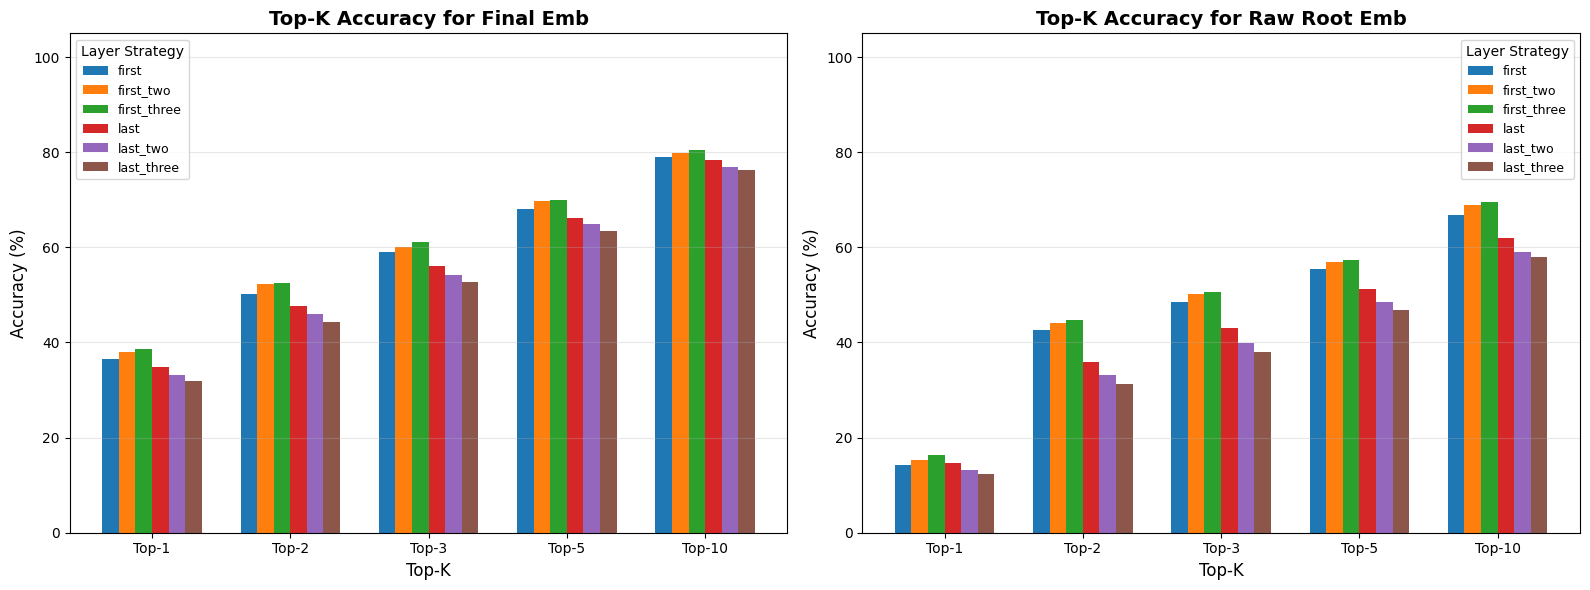

In [23]:
# Visualize results as grouped bar plots
def plot_topk_accuracy_results(total_test_results, k_values, layer_strategies, emb_types):
    """
    Creates grouped bar plots showing top-k accuracy for each embedding type.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, emb_type in enumerate(emb_types):
        ax = axes[idx]
        
        # Prepare data for plotting
        x = np.arange(len(k_values))
        width = 0.12  # Width of each bar
        
        for i, layer_strategy in enumerate(layer_strategies):
            accuracies = []
            for k in k_values:
                hits = total_test_results[layer_strategy][emb_type][k]
                accuracy = sum(hits) / len(hits) * 100 if len(hits) > 0 else 0
                accuracies.append(accuracy)
            
            # Plot bars for this layer strategy
            offset = width * (i - len(layer_strategies)/2 + 0.5)
            ax.bar(x + offset, accuracies, width, label=layer_strategy)
        
        # Formatting
        ax.set_xlabel('Top-K', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        ax.set_title(f'Top-K Accuracy for {emb_type.replace("_", " ").title()}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'Top-{k}' for k in k_values])
        ax.legend(title='Layer Strategy', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()

# Generate the plot
plot_topk_accuracy_results(total_test_results, k_values, layer_strategies, emb_types)

In [24]:
# Calculate and display accuracy statistics in tabular format
print("\n" + "="*100)
print("TOP-K ACCURACY RESULTS (in %)")
print("="*100)

for emb_type in emb_types:
    print(f"\n{'='*100}")
    print(f"EMBEDDING TYPE: {emb_type.upper().replace('_', ' ')}")
    print(f"{'='*100}")
    
    # Create header
    header = f"{'Layer Strategy':<20}"
    for k in k_values:
        header += f"Top-{k:<5}"
    print(f"\n{header}")
    print("-" * 100)
    
    # Print results for each layer strategy
    for layer_strategy in layer_strategies:
        row = f"{layer_strategy:<20}"
        for k in k_values:
            hits = total_test_results[layer_strategy][emb_type][k]
            accuracy = sum(hits) / len(hits) * 100 if len(hits) > 0 else 0
            row += f"{accuracy:>6.2f}%  "
        print(row)
    print()

print("="*100)


TOP-K ACCURACY RESULTS (in %)

EMBEDDING TYPE: FINAL EMB

Layer Strategy      Top-1    Top-2    Top-3    Top-5    Top-10   
----------------------------------------------------------------------------------------------------
first                36.57%   50.16%   58.98%   68.00%   79.10%  
first_two            37.92%   52.20%   60.04%   69.76%   79.84%  
first_three          38.69%   52.49%   61.14%   69.96%   80.45%  
last                 34.82%   47.76%   56.16%   66.08%   78.45%  
last_two             33.06%   46.00%   54.29%   64.86%   76.98%  
last_three           31.96%   44.37%   52.65%   63.43%   76.16%  


EMBEDDING TYPE: RAW ROOT EMB

Layer Strategy      Top-1    Top-2    Top-3    Top-5    Top-10   
----------------------------------------------------------------------------------------------------
first                14.16%   42.65%   48.57%   55.55%   66.78%  
first_two            15.35%   44.12%   50.20%   57.02%   68.94%  
first_three          16.29%   44.78%   50.69%  

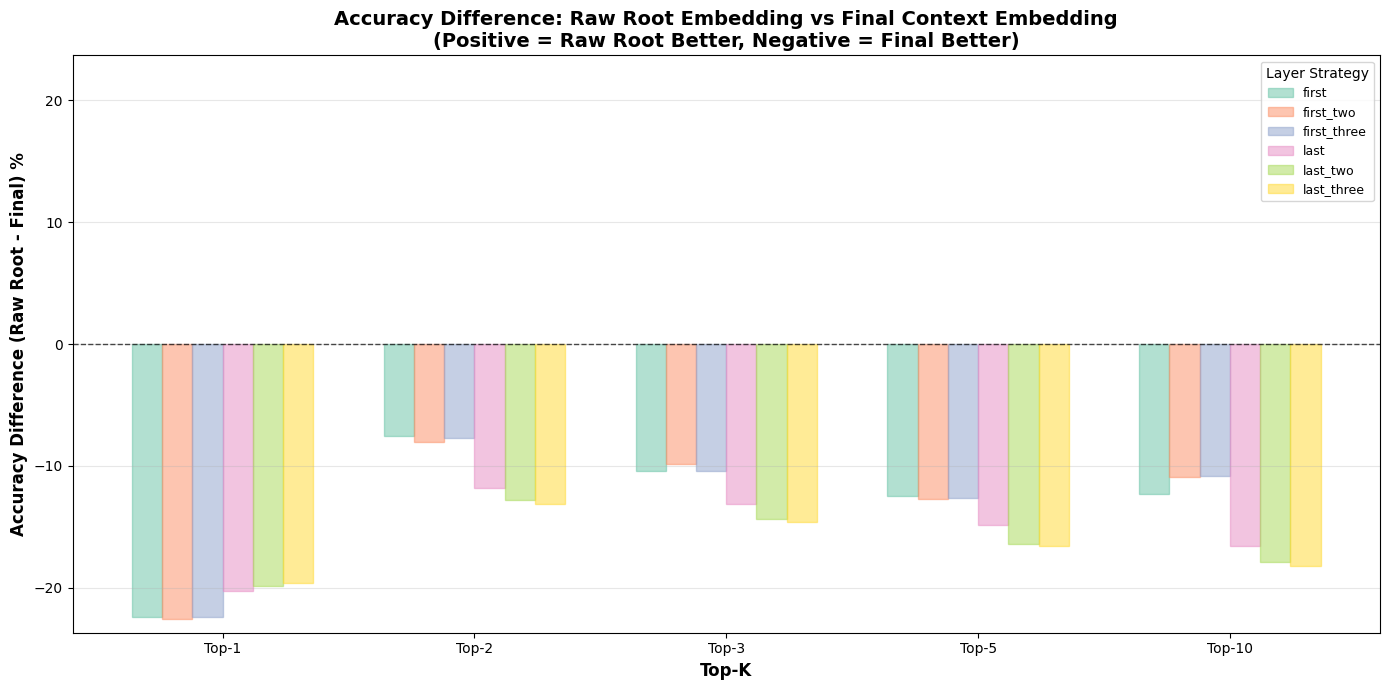

In [25]:
# Plot the difference in accuracy (raw_root - final) for all layers, categorized by k
def plot_accuracy_difference(total_test_results, k_values, layer_strategies, emb_types):
    """
    Plots the difference in accuracy between raw_root_emb and final_emb for each layer strategy.
    Difference = raw_root_emb accuracy - final_emb accuracy
    Positive values mean raw_root performs better, negative means final performs better.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Prepare data for plotting
    x = np.arange(len(k_values))
    width = 0.12  # Width of each bar
    
    for i, layer_strategy in enumerate(layer_strategies):
        differences = []
        for k in k_values:
            # Calculate accuracy for raw_root_emb
            raw_hits = total_test_results[layer_strategy]['raw_root_emb'][k]
            raw_accuracy = sum(raw_hits) / len(raw_hits) * 100 if len(raw_hits) > 0 else 0
            
            # Calculate accuracy for final_emb
            final_hits = total_test_results[layer_strategy]['final_emb'][k]
            final_accuracy = sum(final_hits) / len(final_hits) * 100 if len(final_hits) > 0 else 0
            
            # Calculate difference (raw - final)
            diff = raw_accuracy - final_accuracy
            differences.append(diff)
        
        # Plot bars for this layer strategy
        offset = width * (i - len(layer_strategies)/2 + 0.5)
        bars = ax.bar(x + offset, differences, width, label=layer_strategy)
        
        # Color positive and negative bars differently
        for bar, diff in zip(bars, differences):
            if diff >= 0:
                bar.set_color(plt.cm.Set2(i))
            else:
                bar.set_color(plt.cm.Set2(i))
                bar.set_alpha(0.5)
    
    # Add a horizontal line at y=0 for reference
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Set symmetric y-axis limits to center y=0
    y_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
    y_max = max(y_max, 5)  # Ensure minimum range for visibility
    ax.set_ylim([-y_max, y_max])
    
    # Formatting
    ax.set_xlabel('Top-K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy Difference (Raw Root - Final) %', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy Difference: Raw Root Embedding vs Final Context Embedding\n(Positive = Raw Root Better, Negative = Final Better)', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Top-{k}' for k in k_values])
    ax.legend(title='Layer Strategy', fontsize=9, loc='best')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate the difference plot
plot_accuracy_difference(total_test_results, k_values, layer_strategies, emb_types)

---
# **3. AVERAGE RANK TEST**
## Instead of binary Top-K hits, we collect actual ranks and calculate statistics
### This provides finer granularity: distinguishing rank 1 vs rank 3 vs rank 10

In [26]:
# Function to collect actual rank instead of binary top-k hits
def collect_rank_from_ranked_list(ranked_list, true_m1):
    """
    Finds the actual rank of true_m1 in the ranked list.
    
    Args:
        ranked_list: List of tuples [(m1_keyword, cosine_similarity), ...] sorted by similarity
        true_m1: The actual m1 keyword we're looking for
    
    Returns:
        int: Rank of true_m1 (1-indexed), or None if not found
    """
    for rank, (keyword, _) in enumerate(ranked_list, start=1):
        if keyword == true_m1:
            return rank
    return None  # Should not happen if all keywords are in the dataset

In [27]:
# Function to calculate rank-based metrics
def calculate_rank_metrics(ranks):
    """
    Calculates various statistical metrics from a list of ranks.
    
    Args:
        ranks: List of integer ranks [3, 1, 15, 2, 4, ...]
    
    Returns:
        dict: Dictionary containing mean, median, std, MRR, min, max
    """
    ranks_array = np.array(ranks)
    
    metrics = {
        'mean_rank': float(np.mean(ranks_array)),
        'median_rank': float(np.median(ranks_array)),
        'std_rank': float(np.std(ranks_array)),
        'min_rank': int(np.min(ranks_array)),
        'max_rank': int(np.max(ranks_array)),
        'mrr': float(np.mean(1.0 / ranks_array)),  # Mean Reciprocal Rank
        'total_tests': len(ranks)
    }
    
    return metrics

In [28]:
# Main loop to process all combinations and collect ranks
layer_strategies = ['first', 'first_two', 'first_three', 'last', 'last_two', 'last_three']
emb_types = ['final_emb', 'raw_root_emb']

# Initialize results dictionary to store actual ranks
# Structure: rank_results[layer_strategy][emb_type] = [list of ranks]
rank_results = {}
for layer_strategy in layer_strategies:
    rank_results[layer_strategy] = {}
    for emb_type in emb_types:
        rank_results[layer_strategy][emb_type] = []

# Process all combinations (reusing the same combinations from earlier)
for combo in tqdm(combinations, desc="Processing combinations for rank test"):
    elem1, elem2 = combo['elem1'], combo['elem2']
    metadata = combo['metadata']
    
    m1, w1_list = elem1
    m2, w2_list = elem2
    w1, w2 = w1_list[0], w2_list[0]

    # Get pre-created dataframes from metadata
    DF_ctx_emb_m1 = metadata['DF_m1']
    DF_ctx_emb_w1 = metadata['DF_w1']
    DF_ctx_emb_m2 = metadata['DF_m2']
    DF_ctx_emb_w2 = metadata['DF_w2']

    # Results contains Eq (predicted embedding) for all layer strategies and both embedding types
    results = run_bats_analogy_test(DF_ctx_emb_m1, DF_ctx_emb_w1,
                                    DF_ctx_emb_m2, DF_ctx_emb_w2)
    
    # For each layer strategy and embedding type, get the rank
    for layer_strategy in layer_strategies:
        for emb_type in emb_types:
            # Get the predicted Eq embedding
            Eq_embedding = results[layer_strategy][emb_type]['predicted_a_final_emb'] if emb_type == 'final_emb' else results[layer_strategy][emb_type]['predicted_a_raw_root_emb']
            
            # Rank all m1 embeddings against this Eq
            ranked_list = rank_m1_against_Eq(Eq_embedding, all_m1_embeddings, layer_strategy, emb_type)
            
            # Collect the actual rank
            actual_rank = collect_rank_from_ranked_list(ranked_list, m1)
            
            if actual_rank is not None:
                rank_results[layer_strategy][emb_type].append(actual_rank)

print("Rank collection complete!")

Processing combinations for rank test:   0%|          | 0/2450 [00:00<?, ?it/s]/tmp/ipykernel_3719140/4235922348.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'cosine_similarity': float(raw_root_emb_cosine_sim)
/tmp/ipykernel_3719140/1855354982.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  similarities.append((m1_keyword, float(cos_sim)))
Processing combinations for rank test: 100%|██████████| 2450/2450 [05:21<00:00,  7.62it/s]

Rank collection complete!


In [29]:
# Calculate metrics for all layer strategies and embedding types
rank_metrics = {}
for layer_strategy in layer_strategies:
    rank_metrics[layer_strategy] = {}
    for emb_type in emb_types:
        ranks = rank_results[layer_strategy][emb_type]
        rank_metrics[layer_strategy][emb_type] = calculate_rank_metrics(ranks)

print("Rank metrics calculated!")

Rank metrics calculated!


In [30]:
# Display rank statistics in tabular format
print("\n" + "="*120)
print("AVERAGE RANK TEST RESULTS")
print("="*120)

for emb_type in emb_types:
    print(f"\n{'='*120}")
    print(f"EMBEDDING TYPE: {emb_type.upper().replace('_', ' ')}")
    print(f"{'='*120}")
    
    # Create header
    header = f"{'Layer Strategy':<15} {'Mean Rank':<12} {'Median':<10} {'Std Dev':<10} {'Min':<8} {'Max':<8} {'MRR':<10} {'Tests':<8}"
    print(f"\n{header}")
    print("-" * 120)
    
    # Print results for each layer strategy
    for layer_strategy in layer_strategies:
        metrics = rank_metrics[layer_strategy][emb_type]
        row = (f"{layer_strategy:<15} "
               f"{metrics['mean_rank']:<12.2f} "
               f"{metrics['median_rank']:<10.1f} "
               f"{metrics['std_rank']:<10.2f} "
               f"{metrics['min_rank']:<8} "
               f"{metrics['max_rank']:<8} "
               f"{metrics['mrr']:<10.4f} "
               f"{metrics['total_tests']:<8}")
        print(row)
    print()

print("="*120)
print("\nNote: Lower mean/median rank is better. Higher MRR (Mean Reciprocal Rank) is better.")


AVERAGE RANK TEST RESULTS

EMBEDDING TYPE: FINAL EMB

Layer Strategy  Mean Rank    Median     Std Dev    Min      Max      MRR        Tests   
------------------------------------------------------------------------------------------------------------------------
first           7.64         2.0        11.50      1        50       0.5089     2450    
first_two       7.31         2.0        11.19      1        50       0.5224     2450    
first_three     7.11         2.0        10.94      1        50       0.5285     2450    
last            7.61         3.0        10.89      1        50       0.4909     2450    
last_two        7.96         3.0        11.09      1        50       0.4750     2450    
last_three      8.24         3.0        11.21      1        50       0.4628     2450    


EMBEDDING TYPE: RAW ROOT EMB

Layer Strategy  Mean Rank    Median     Std Dev    Min      Max      MRR        Tests   
--------------------------------------------------------------------------------

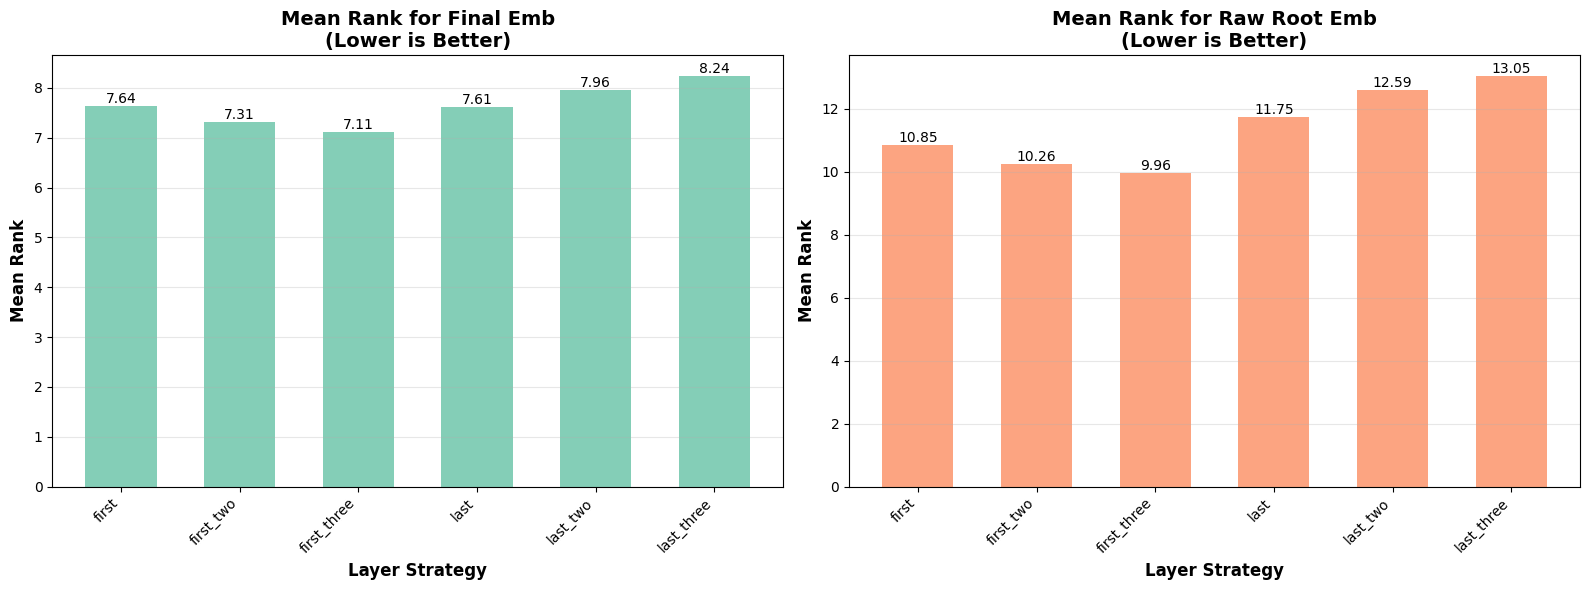

In [31]:
# Visualization 1: Mean Rank Comparison (Bar Chart)
def plot_mean_rank_comparison(rank_metrics, layer_strategies, emb_types):
    """
    Creates grouped bar plots comparing mean ranks.
    Lower bars are better (lower rank = better performance).
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, emb_type in enumerate(emb_types):
        ax = axes[idx]
        
        # Extract mean ranks
        mean_ranks = [rank_metrics[ls][emb_type]['mean_rank'] for ls in layer_strategies]
        
        # Create bar chart
        x = np.arange(len(layer_strategies))
        bars = ax.bar(x, mean_ranks, width=0.6, alpha=0.8, color=plt.cm.Set2(idx))
        
        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mean_ranks[i]:.2f}',
                   ha='center', va='bottom', fontsize=10)
        
        # Formatting
        ax.set_xlabel('Layer Strategy', fontsize=12, fontweight='bold')
        ax.set_ylabel('Mean Rank', fontsize=12, fontweight='bold')
        ax.set_title(f'Mean Rank for {emb_type.replace("_", " ").title()}\n(Lower is Better)', 
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(layer_strategies, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate the plot
plot_mean_rank_comparison(rank_metrics, layer_strategies, emb_types)

/tmp/ipykernel_3719140/3225842590.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=layer_strategies, patch_artist=True,
/tmp/ipykernel_3719140/3225842590.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=layer_strategies, patch_artist=True,


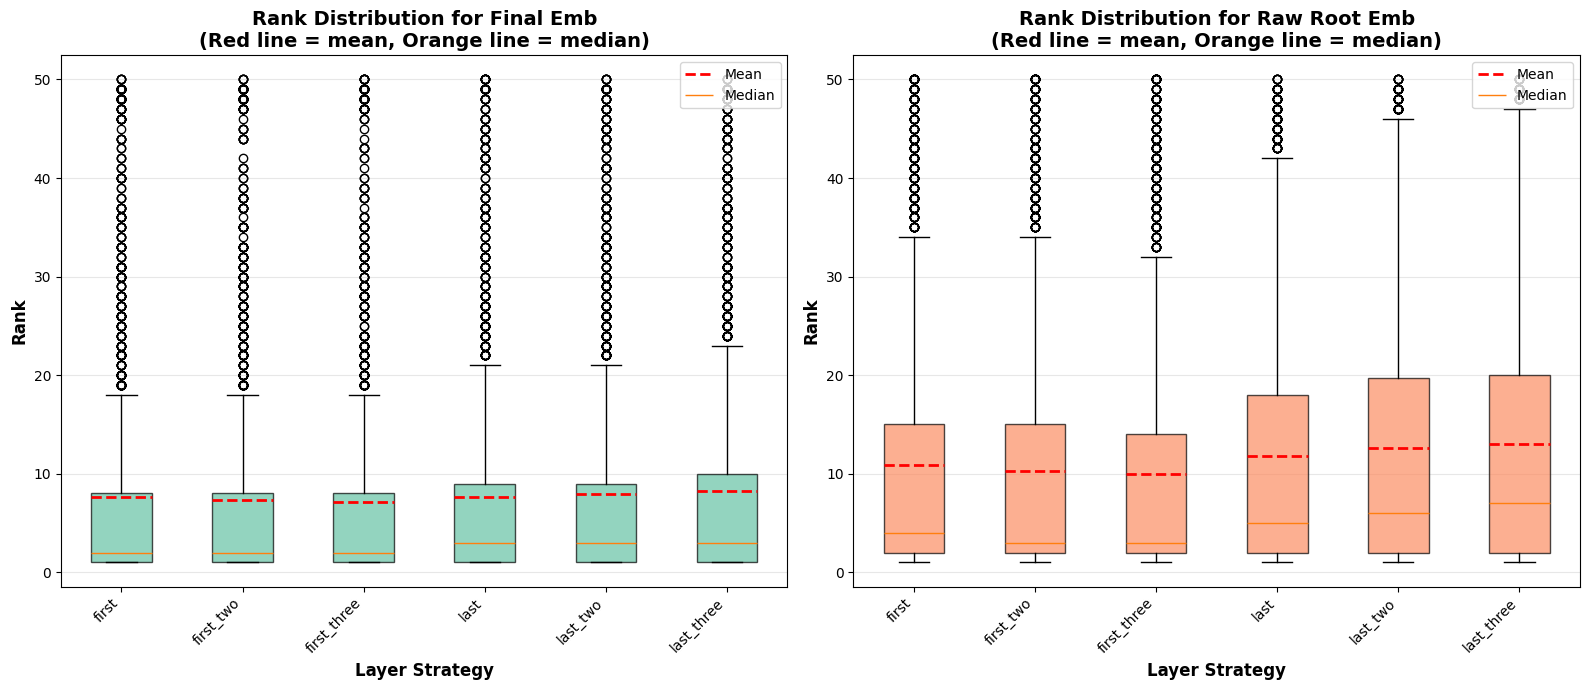

In [32]:
# Visualization 2: Box Plot showing rank distributions
def plot_rank_distributions(rank_results, layer_strategies, emb_types):
    """
    Creates box plots showing the distribution of ranks for each layer strategy.
    Shows median, quartiles, and outliers.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for idx, emb_type in enumerate(emb_types):
        ax = axes[idx]
        
        # Prepare data for box plot
        data_to_plot = [rank_results[ls][emb_type] for ls in layer_strategies]
        
        # Create box plot
        bp = ax.boxplot(data_to_plot, labels=layer_strategies, patch_artist=True,
                       showmeans=True, meanline=True)
        
        # Color the boxes
        for patch in bp['boxes']:
            patch.set_facecolor(plt.cm.Set2(idx))
            patch.set_alpha(0.7)
        
        # Color mean line
        for mean_line in bp['means']:
            mean_line.set_color('red')
            mean_line.set_linewidth(2)
        
        # Formatting
        ax.set_xlabel('Layer Strategy', fontsize=12, fontweight='bold')
        ax.set_ylabel('Rank', fontsize=12, fontweight='bold')
        ax.set_title(f'Rank Distribution for {emb_type.replace("_", " ").title()}\n(Red line = mean, Orange line = median)', 
                    fontsize=14, fontweight='bold')
        ax.set_xticklabels(layer_strategies, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        # Add legend
        ax.legend([bp['means'][0], bp['medians'][0]], ['Mean', 'Median'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Generate the box plot
plot_rank_distributions(rank_results, layer_strategies, emb_types)

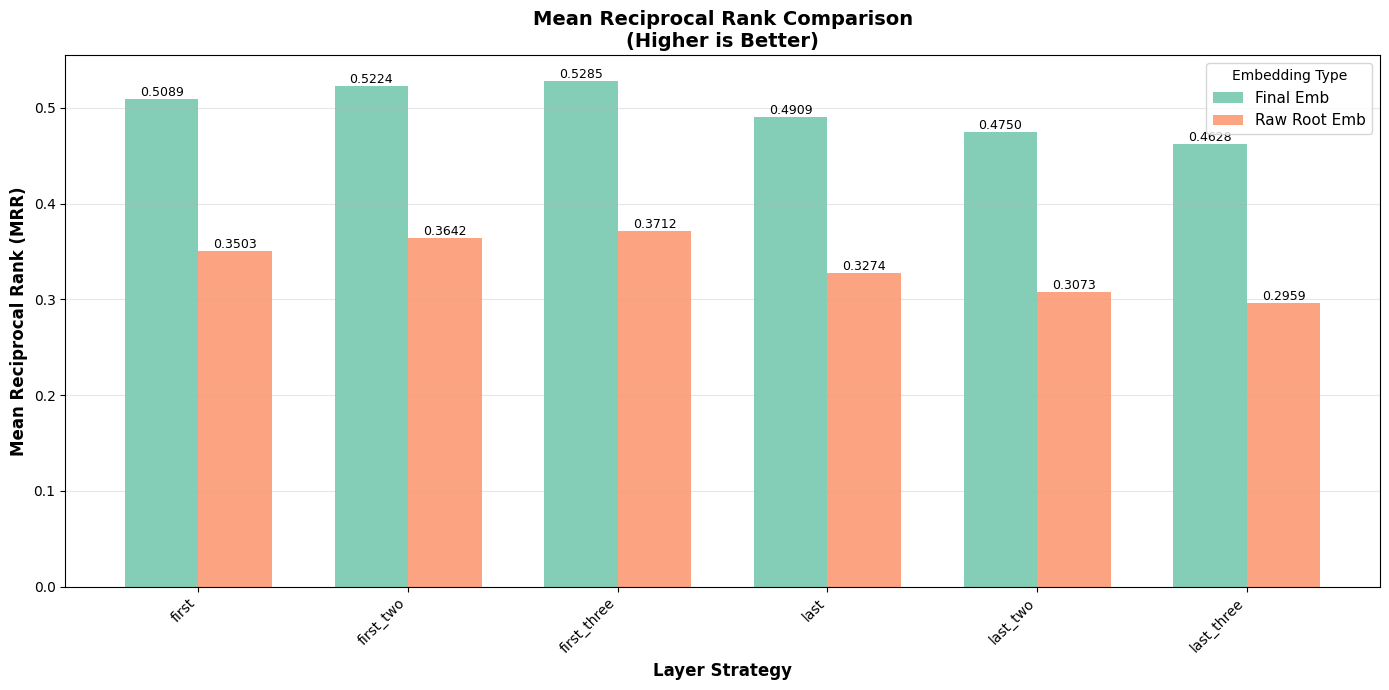

In [33]:
# Visualization 3: Mean Reciprocal Rank (MRR) Comparison
def plot_mrr_comparison(rank_metrics, layer_strategies, emb_types):
    """
    Creates grouped bar plots comparing MRR (Mean Reciprocal Rank).
    Higher bars are better (higher MRR = better performance).
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(len(layer_strategies))
    width = 0.35
    
    for idx, emb_type in enumerate(emb_types):
        # Extract MRR values
        mrr_values = [rank_metrics[ls][emb_type]['mrr'] for ls in layer_strategies]
        
        # Create bars
        offset = width * idx
        bars = ax.bar(x + offset, mrr_values, width, label=emb_type.replace('_', ' ').title(),
                     alpha=0.8, color=plt.cm.Set2(idx))
        
        # Add value labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mrr_values[i]:.4f}',
                   ha='center', va='bottom', fontsize=9)
    
    # Formatting
    ax.set_xlabel('Layer Strategy', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Reciprocal Rank (MRR)', fontsize=12, fontweight='bold')
    ax.set_title('Mean Reciprocal Rank Comparison\n(Higher is Better)', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(layer_strategies, rotation=45, ha='right')
    ax.legend(title='Embedding Type', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate the MRR plot
plot_mrr_comparison(rank_metrics, layer_strategies, emb_types)

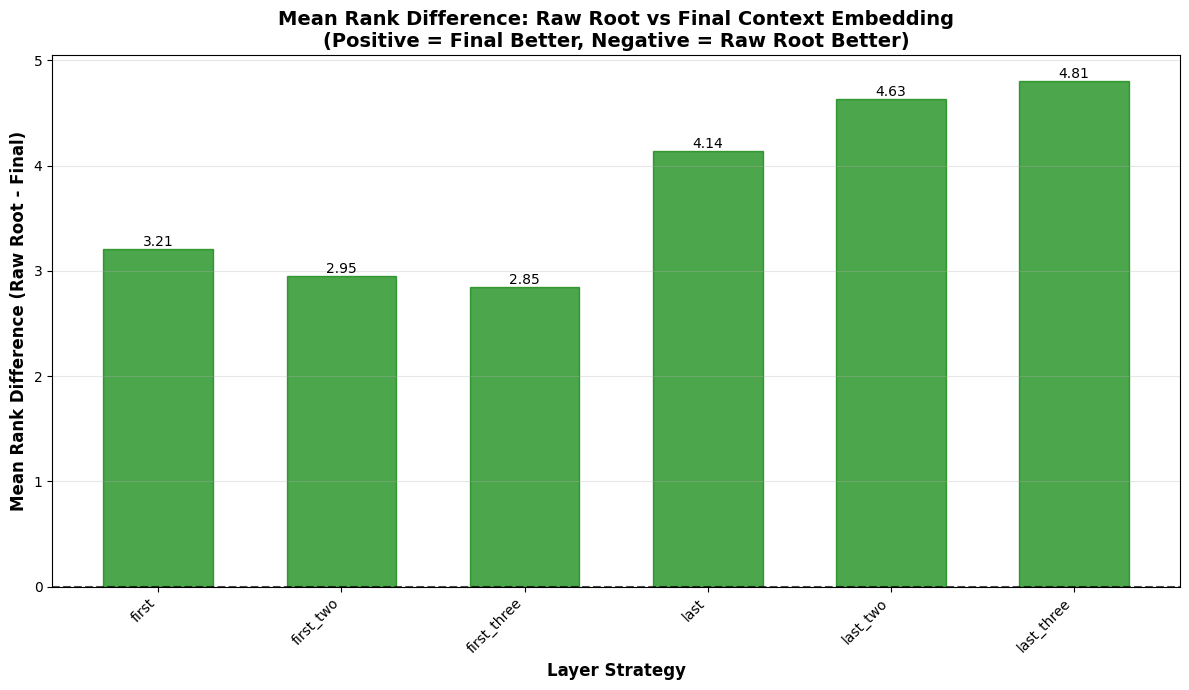

In [34]:
# Visualization 4: Rank difference (raw_root - final) for mean rank
def plot_mean_rank_difference(rank_metrics, layer_strategies):
    """
    Plots the difference in mean rank between raw_root_emb and final_emb.
    Difference = raw_root mean rank - final mean rank
    Positive values mean final_emb performs better (has lower rank).
    Negative values mean raw_root performs better.
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Calculate differences
    differences = []
    for ls in layer_strategies:
        raw_mean = rank_metrics[ls]['raw_root_emb']['mean_rank']
        final_mean = rank_metrics[ls]['final_emb']['mean_rank']
        diff = raw_mean - final_mean  # Positive = final is better
        differences.append(diff)
    
    # Create bar chart
    x = np.arange(len(layer_strategies))
    bars = ax.bar(x, differences, width=0.6, alpha=0.8)
    
    # Color bars based on sign
    for bar, diff in zip(bars, differences):
        if diff > 0:
            bar.set_color('green')  # Final embedding is better
            bar.set_alpha(0.7)
        else:
            bar.set_color('red')  # Raw root is better
            bar.set_alpha(0.7)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{differences[i]:.2f}',
               ha='center', va='bottom' if height > 0 else 'top', fontsize=10)
    
    # Add a horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_xlabel('Layer Strategy', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Rank Difference (Raw Root - Final)', fontsize=12, fontweight='bold')
    ax.set_title('Mean Rank Difference: Raw Root vs Final Context Embedding\n(Positive = Final Better, Negative = Raw Root Better)', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(layer_strategies, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate the difference plot
plot_mean_rank_difference(rank_metrics, layer_strategies)

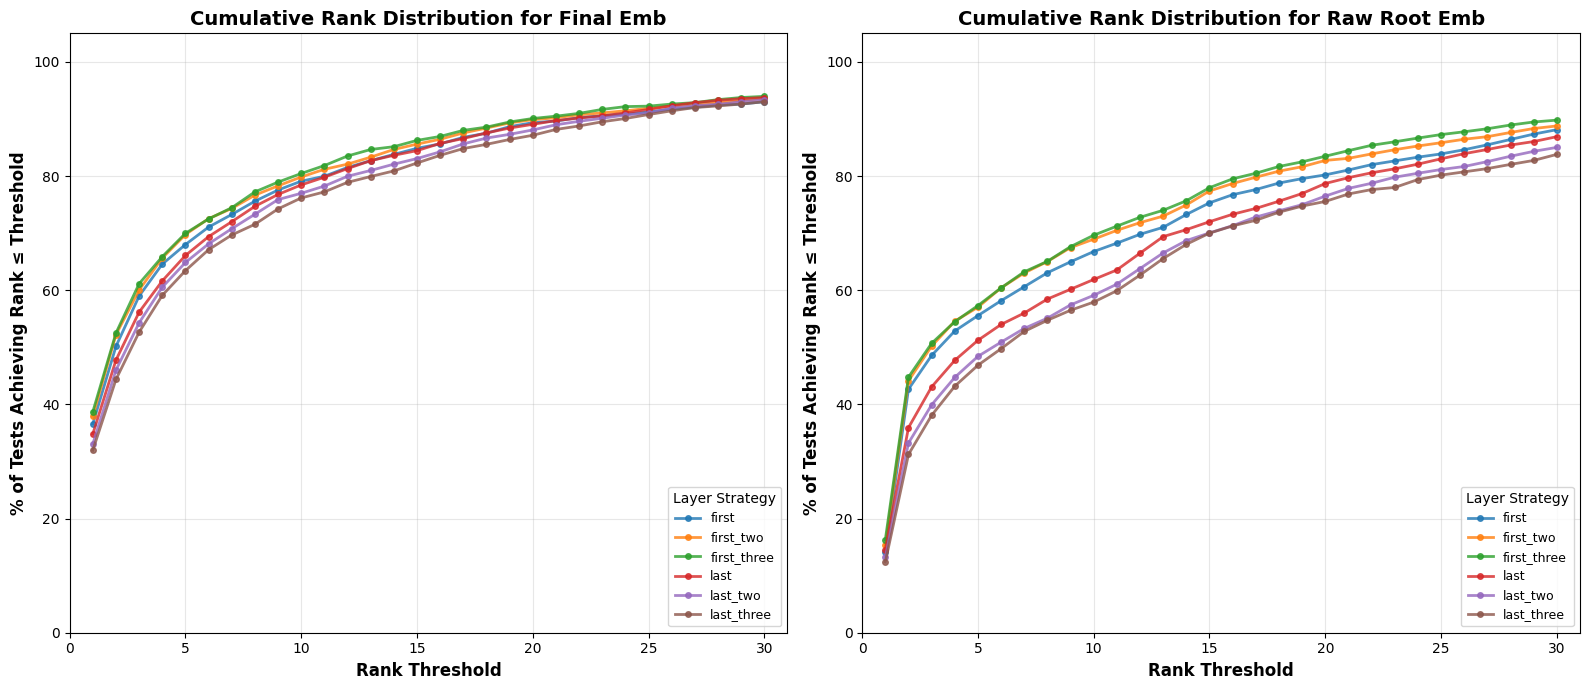

In [35]:
# Visualization 5: Cumulative Distribution - What % of tests achieve rank <= X
def plot_cumulative_rank_distribution(rank_results, layer_strategies, emb_types):
    """
    Creates cumulative distribution curves showing what percentage of tests
    achieve a rank less than or equal to X.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    max_rank_to_plot = 30  # Focus on first 30 ranks
    
    for idx, emb_type in enumerate(emb_types):
        ax = axes[idx]
        
        for i, layer_strategy in enumerate(layer_strategies):
            ranks = np.array(rank_results[layer_strategy][emb_type])
            
            # Calculate cumulative distribution
            x_values = range(1, max_rank_to_plot + 1)
            y_values = [(ranks <= x).sum() / len(ranks) * 100 for x in x_values]
            
            # Plot the curve
            ax.plot(x_values, y_values, marker='o', markersize=4, linewidth=2,
                   label=layer_strategy, alpha=0.8)
        
        # Formatting
        ax.set_xlabel('Rank Threshold', fontsize=12, fontweight='bold')
        ax.set_ylabel('% of Tests Achieving Rank ≤ Threshold', fontsize=12, fontweight='bold')
        ax.set_title(f'Cumulative Rank Distribution for {emb_type.replace("_", " ").title()}',
                    fontsize=14, fontweight='bold')
        ax.legend(title='Layer Strategy', fontsize=9, loc='lower right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, max_rank_to_plot + 1])
        ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()

# Generate the cumulative distribution plot
plot_cumulative_rank_distribution(rank_results, layer_strategies, emb_types)

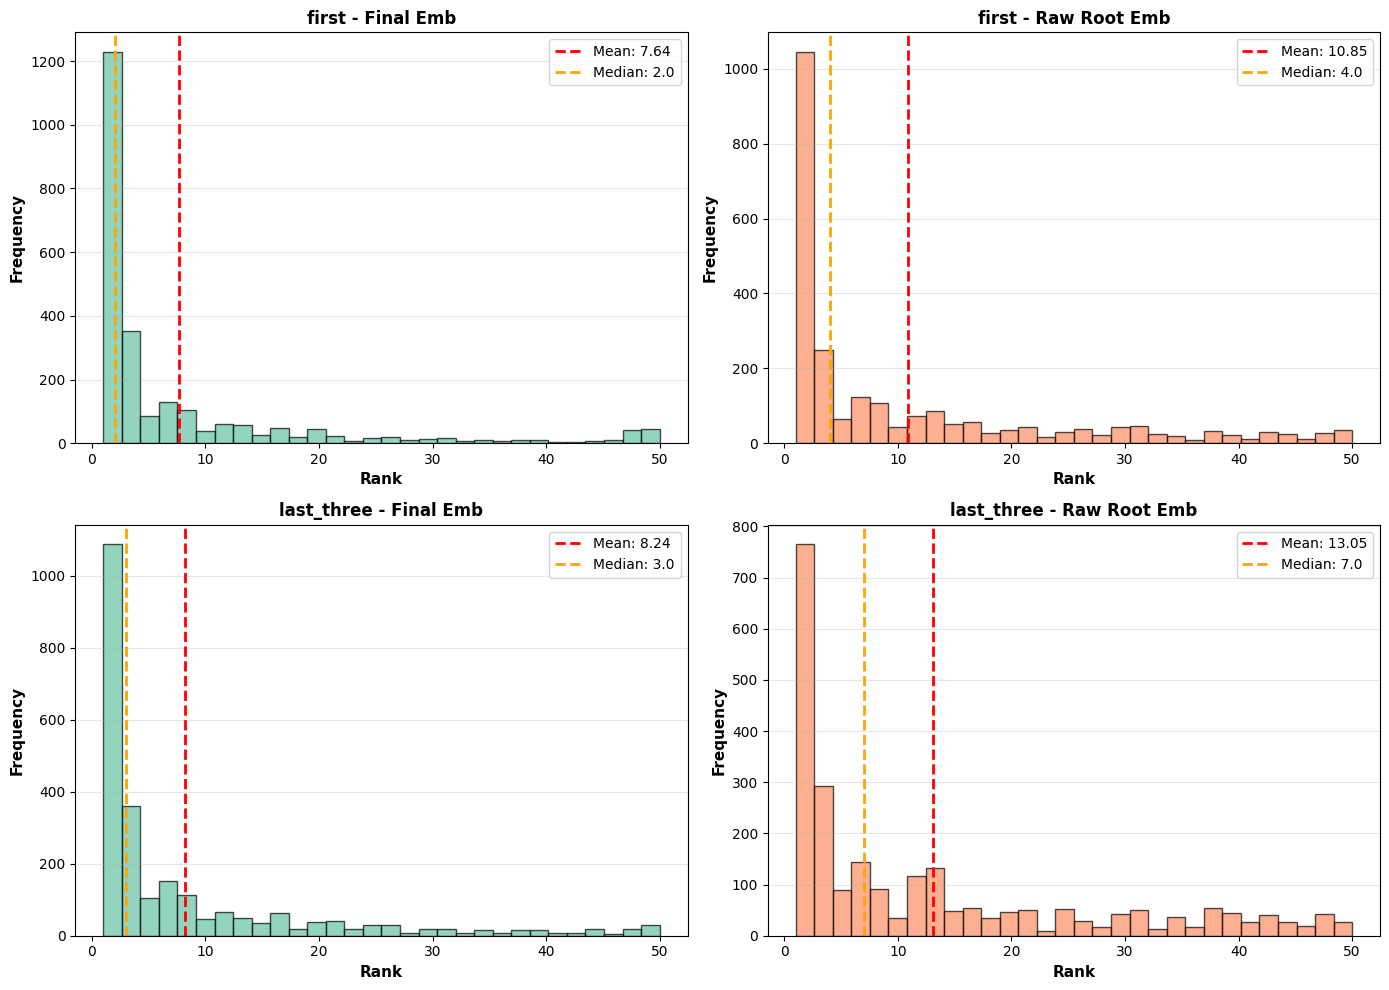

In [36]:
# Visualization 6: Rank Histogram for selected layer strategies
def plot_rank_histograms(rank_results, selected_strategies, emb_types):
    """
    Creates histograms showing the frequency distribution of ranks
    for selected layer strategies.
    """
    n_strategies = len(selected_strategies)
    fig, axes = plt.subplots(n_strategies, 2, figsize=(14, 5 * n_strategies))
    
    if n_strategies == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, layer_strategy in enumerate(selected_strategies):
        for col_idx, emb_type in enumerate(emb_types):
            ax = axes[row_idx, col_idx]
            
            ranks = rank_results[layer_strategy][emb_type]
            
            # Create histogram
            ax.hist(ranks, bins=30, alpha=0.7, color=plt.cm.Set2(col_idx), edgecolor='black')
            
            # Add mean and median lines
            mean_rank = np.mean(ranks)
            median_rank = np.median(ranks)
            ax.axvline(mean_rank, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_rank:.2f}')
            ax.axvline(median_rank, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_rank:.1f}')
            
            # Formatting
            ax.set_xlabel('Rank', fontsize=11, fontweight='bold')
            ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
            ax.set_title(f'{layer_strategy} - {emb_type.replace("_", " ").title()}', 
                        fontsize=12, fontweight='bold')
            ax.legend(loc='upper right')
            ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate histograms for a few selected strategies
selected_strategies = ['first', 'last_three']  # Choose strategies to visualize
plot_rank_histograms(rank_results, selected_strategies, emb_types)

## Summary of Average Rank Test

This test provides more granular insights than the Top-K accuracy test:

1. **Mean Rank**: Shows average position of correct answer (lower is better)
2. **Median Rank**: More robust to outliers than mean
3. **MRR (Mean Reciprocal Rank)**: Standard IR metric, gives higher weight to top ranks
4. **Box Plots**: Show distribution, outliers, and consistency
5. **Cumulative Distribution**: Shows what % of tests achieve rank ≤ threshold
6. **Histograms**: Show full rank frequency distribution

**Key Advantages**:
- Distinguishes excellent (rank 1-2) from acceptable (rank 3-5) performance
- Identifies consistency vs variability in performance
- Reveals where hierarchical context helps most